In [1]:
import zbi
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import ticker
from math import pi
from cmb.style import apply

apply()
%matplotlib inline
run_dir = "../runs/planck_lite_r2"

In [2]:
def plot_spectrum_panels(
    panels,
    mode="dl",
    colors=None,
    figsize=(14, 12),
    legend_fontsize=15,
    output_path=None,
):
    if colors is None:
        colors = {"tt": "#1f77b4", "te": "#ff7f0e", "ee": "#2ca02c"}
    n_panels = len(panels)

    fig = plt.figure(figsize=figsize)
    outer_gs = GridSpec(n_panels, 1, hspace=0.3)

    for row_idx, p in enumerate(panels):
        inner_gs = GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer_gs[row_idx],
            height_ratios=[3, 1], hspace=0.08,
        )
        ell = p["ell"]
        fac = ell * (ell + 1) / (2 * pi) if mode == "dl" else 1.0
        data = p["data"] * fac
        model = p["model"] * fac
        cl_key = p["label"].lower()
        color = colors.get(cl_key, "#1f77b4")
        dl = r'D_\ell' if mode == "dl" else r'C_\ell'

        ax1 = fig.add_subplot(inner_gs[0])
        if p.get("sims") is not None:
            sims = p["sims"] * fac
            for s in sims:
                ax1.plot(ell, s, color=color, alpha=0.08, lw=0.5)
            ci_lo = np.percentile(sims, 2.5, axis=0)
            ci_hi = np.percentile(sims, 97.5, axis=0)
            ax1.fill_between(ell, ci_lo, ci_hi, alpha=0.12, color=color, label="95% CI")
            resid = np.mean(sims, axis=0) - data
            resid_lo = ci_lo - data
            resid_hi = ci_hi - data
        else:
            errs = p["errors"] * fac if p.get("errors") is not None else None
            ax1.errorbar(ell, data, yerr=errs, fmt="k.", ms=2.5,
                         capsize=0, elinewidth=0.5, label="Planck data", zorder=10)
            resid = model - data
            resid_lo = resid_hi = None
        ax1.plot(ell, model, "-", color=color, lw=1.5, label="Best fit")
        ylab = f"${dl}^{{\\mathrm{{{p['label']}}}}}$ [$\\mu$K$^2$]"
        ax1.set_ylabel(ylab)
        if row_idx == 0:
            ax1.legend(fontsize=legend_fontsize, loc="upper right")
        ax1.tick_params(labelbottom=False)
        ax1.set_xlim(ell[0], ell[-1])

        ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
        ax2.plot(ell, resid, ".", color=color, ms=3)
        if resid_lo is not None:
            ax2.fill_between(ell, resid_lo, resid_hi, alpha=0.15, color=color)
        ax2.axhline(0, color="gray", ls="--", lw=0.6)
        ax2.set_ylabel(r'$\Delta$ [$\mu$K$^2$]')
        ax2.set_xlim(ell[0], ell[-1])
        ax2.yaxis.set_major_locator(ticker.MaxNLocator(4))
        for spine in ax2.spines.values():
            spine.set_linewidth(1.0)
        ax2.tick_params(labelbottom=True)
        if row_idx == n_panels - 1:
            ax2.set_xlabel(r'$\ell$')

    fig.align_ylabels()
    if output_path:
        fig.savefig(output_path)
    return fig

Las implementaciones concretas del simulador y la red de embedding no se muestran en detalle en este notebook, solo se usan. Para la lógica de carga de datos, reconstrucción de la matriz de binning y la clase del simulador que sigue la API de zbi, ver `cmb/simulators/planck_lite_r1.py`. Para la red de embedding que sigue la API de PyTorch, ver `cmb/embeddings/mlp_embedding.py`.

## 1. Setup Experimental

### 1.1 La likelihood PLIK lite

El conjunto de datos de Planck 2018 incluye una likelihood simplificada llamada `plik_lite` que emula el comportamiento estadístico de los bandpowers TT, TE y EE del CMB. La forma funcional de la likelihood es gaussiana:

$$p(x|\theta) = \mathcal{N}\left(B \cdot D_\ell(\theta),\, C\right)$$

donde $x \in \mathbb{R}^{613}$ es el vector de bandpowers observados, $B \cdot D_\ell(\theta)$ es el modelo teórico evaluado en los parámetros cosmológicos $\theta$ y agrupado en bins de multipolo, y $C$ es la matriz de covarianza de $613 \times 613$ que codifica tanto el ruido instrumental como las correlaciones entre bins y entre espectros. Los 613 bins se distribuyen en 3 espectros: TT (215 bins), TE (199 bins) y EE (199 bins).

La covarianza $C$ tiene una estructura de bloques, con un bloque diagonal por espectro y términos fuera de diagonal que capturan las correlaciones TT-TE, TT-EE y TE-EE. A continuación se muestra la covarianza completa.

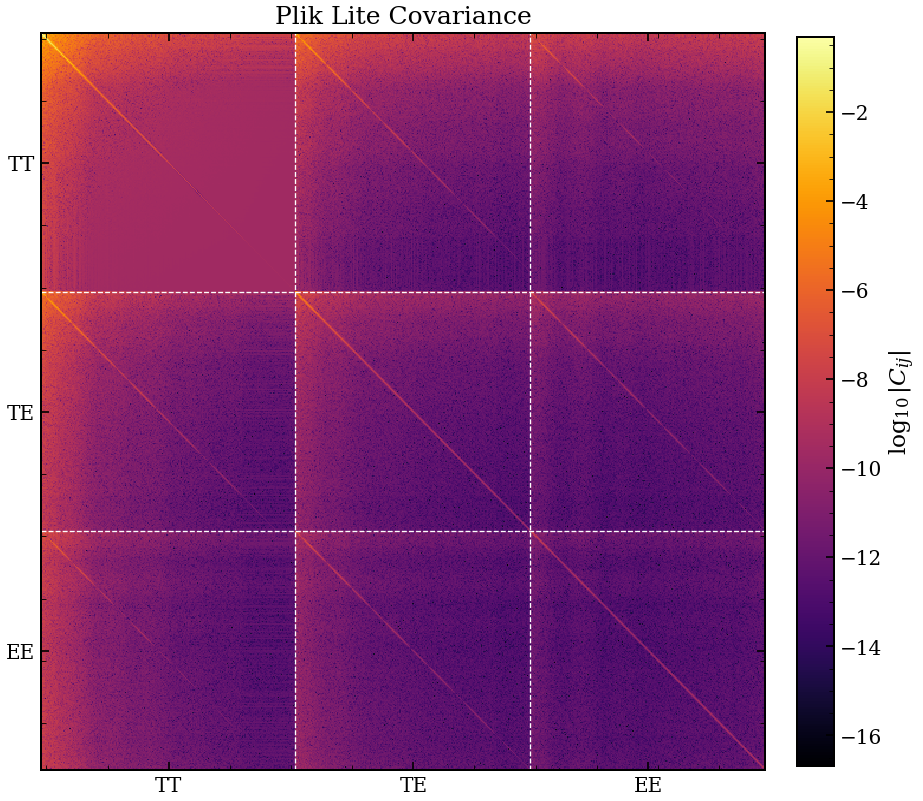

In [3]:
from cmb.simulators import PlanckLiteSimulatorR1

sim = PlanckLiteSimulatorR1(use_cl=['tt', 'te', 'ee'])

sizes = [len(sim.bin_indices[cl]) for cl in ['tt', 'te', 'ee']]
bounds = np.cumsum([0] + sizes)
labels = ['TT', 'TE', 'EE']
mids = [(bounds[i] + bounds[i+1]) / 2 for i in range(3)]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(np.log10(np.abs(sim.cov)), cmap='inferno', interpolation="nearest", aspect="auto")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\log_{10}|C_{ij}|$')

for b in bounds[1:-1]:
    ax.axhline(b - 0.5, color='white', lw=0.8, ls='--')
    ax.axvline(b - 0.5, color='white', lw=0.8, ls='--')

ax.grid(False)
ax.set_xticks(mids)
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(mids)
ax.set_yticklabels(labels, fontsize=12)
ax.set_title('Plik Lite Covariance')
plt.tight_layout()
plt.show()

### 1.2 Espectros de potencia y modelo teórico

Los datos observacionales de Planck se comparan con el modelo teórico fiducial evaluado en los parámetros cosmológicos de referencia provenientes de la tabla 2 de arXiv:1807.06209v4. Los errores provienen de la diagonal de la matriz de covarianza $C$. Los residuos en el subplot inferior verifican la consistencia entre el modelo y los datos.

In [4]:
ell_centres = {}
cl_errors = {}
idx = 0
for cl in ['tt', 'te', 'ee']:
    n = len(sim.bin_indices[cl])
    ell_centres[cl] = (sim.lmin_per_bin[cl][:n] + sim.lmax_per_bin[cl][:n]) / 2
    row = np.arange(idx, idx + n)
    cl_errors[cl] = np.sqrt(np.diag(sim.cov))[row]
    idx += n

In [5]:
theta_true = torch.tensor([
    0.02237, # ombh2
    0.1200,  # omch2
    1.04092, # theta_mc
    0.0544,  # tau
    3.044,   # logA
    0.9649   # ns
])
clean = sim.model(theta_true)
idx = 0
clean_by_cl = {}
for cl in ['tt', 'te', 'ee']:
    n = len(sim.bin_indices[cl])
    clean_by_cl[cl] = clean[idx:idx+n]
    idx += n

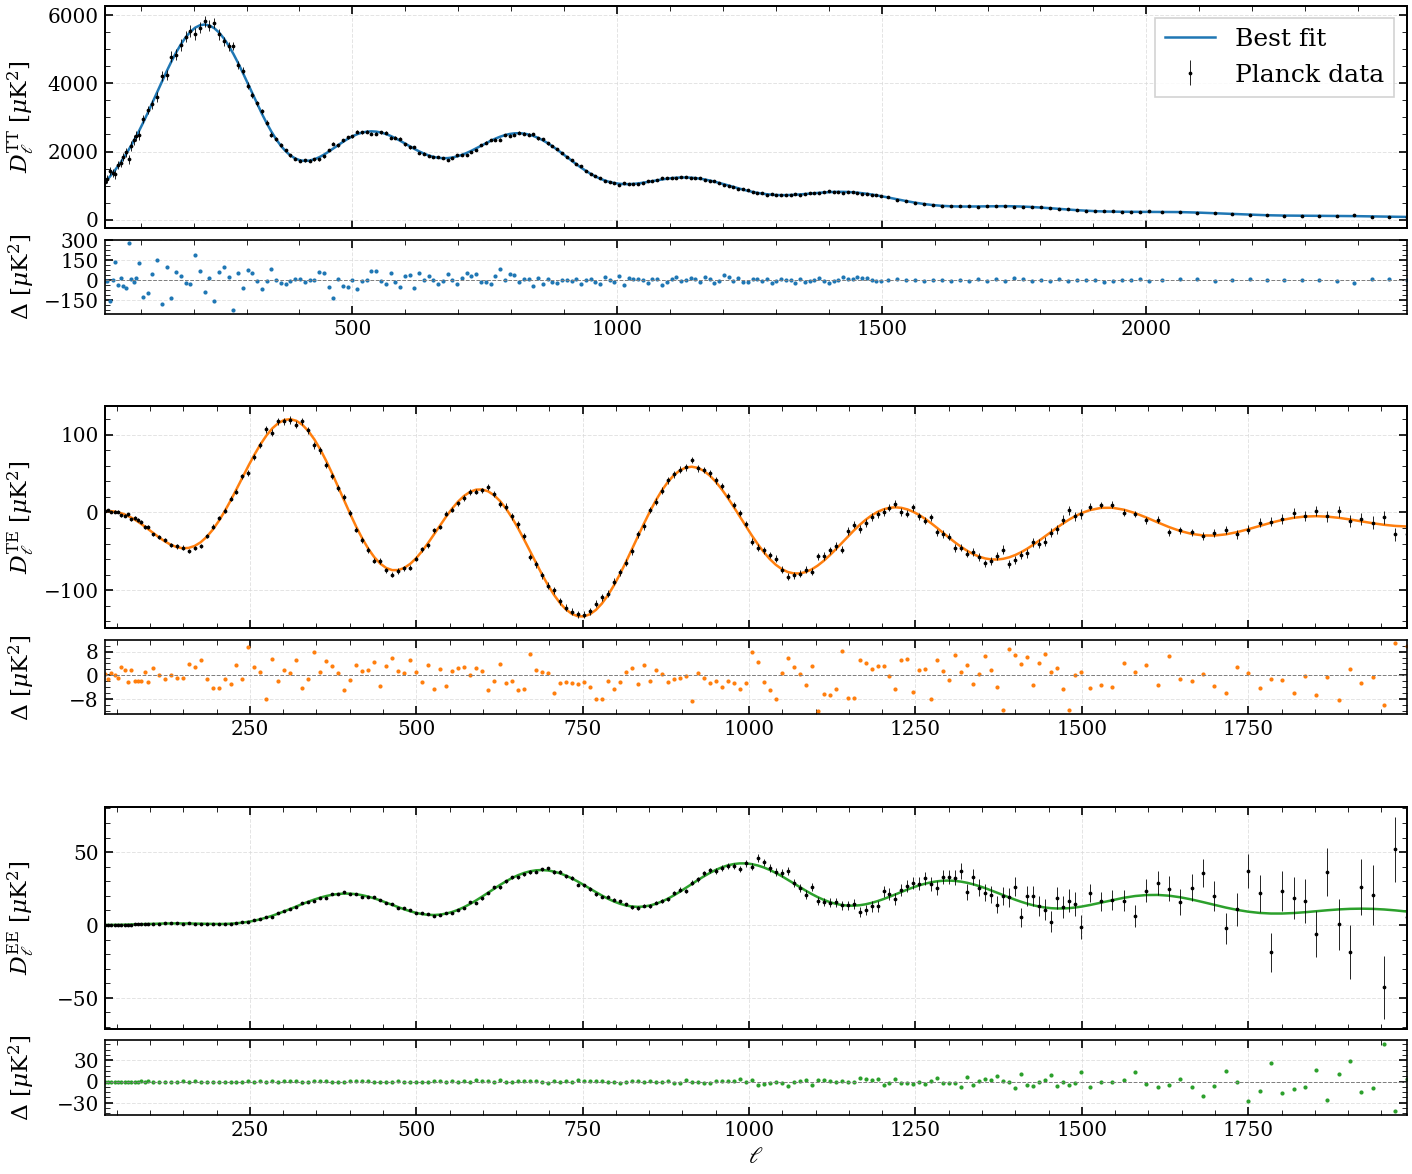

In [6]:
obs_by_cl = {}
idx = 0
for cl in ['tt', 'te', 'ee']:
    n = len(sim.bin_indices[cl])
    obs_by_cl[cl] = sim.X_data[idx:idx+n]
    idx += n

panels = [
    {"ell": ell_centres[cl], "data": obs_by_cl[cl], "model": clean_by_cl[cl],
     "errors": cl_errors[cl], "sims": None, "label": cl.upper()}
    for cl in ['tt', 'te', 'ee']
]
plot_spectrum_panels(panels, mode="dl")
plt.show()

### 1.3 Simulador estocástico gaussiano

Dado que la likelihood es gaussiana, un simulador estocástico se construye de forma directa: para un vector de parámetros $\theta$, primero se calcula el espectro teórico $B \cdot D_\ell(\theta)$, y luego se agrega ruido correlacionado $\varepsilon \sim \mathcal{N}(0, C)$:

$$x = B \cdot D_\ell(\theta) + L\varepsilon$$

donde $C = LL^T$ es la descomposición de Cholesky de la covarianza. Cada llamada al simulador produce una realización distinta de los bandpowers, capturando la variabilidad inherente del experimento. La Figura 2 muestra 100 realizaciones estocásticas (líneas transparentes) junto con el intervalo de confianza del 95% (región sombreada) calculada a partir de los percentiles 2.5 y 97.5.

In [7]:
n_real = 100
sims_noisy = {cl: [] for cl in ['tt', 'te', 'ee']}
for i in range(n_real):
    x = sim.simulate(theta_true, seed=i).numpy()
    idx = 0
    for cl in ['tt', 'te', 'ee']:
        n = len(sim.bin_indices[cl])
        sims_noisy[cl].append(x[idx:idx+n])
        idx += n

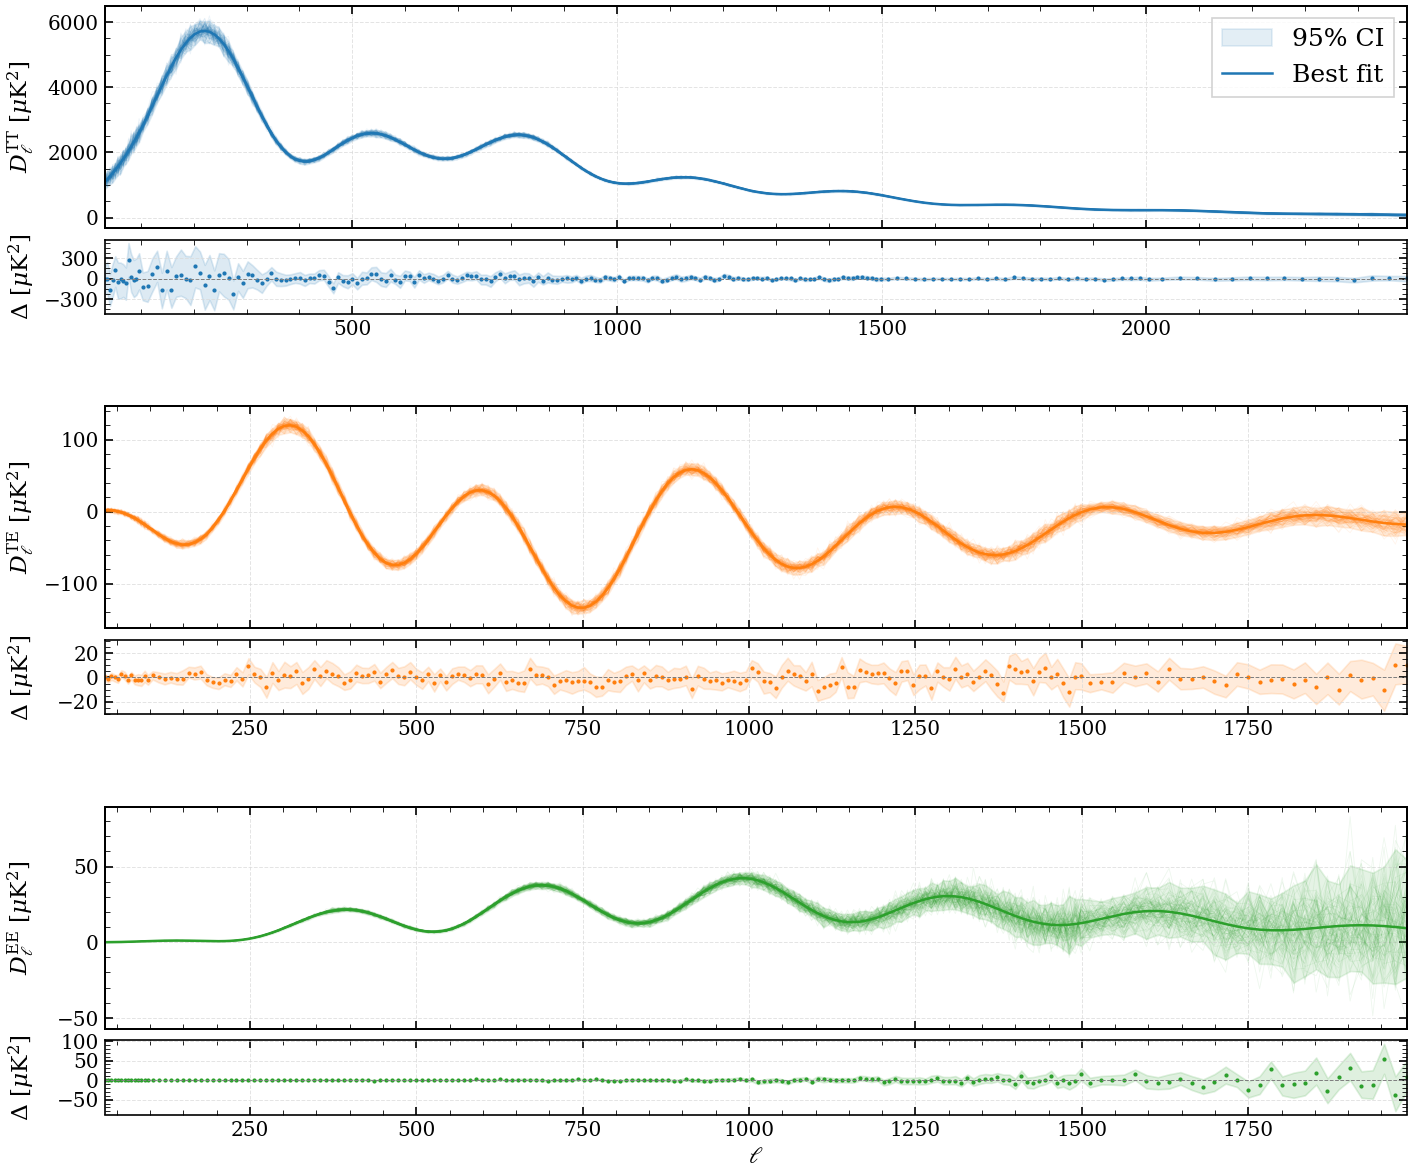

In [8]:
panels_stoch = [
    {"ell": ell_centres[cl], "data": obs_by_cl[cl], "model": clean_by_cl[cl],
     "sims": np.array(sims_noisy[cl]), "errors": None, "label": cl.upper()}
    for cl in ['tt', 'te', 'ee']
]
plot_spectrum_panels(panels_stoch, mode="dl")
plt.show()

### 1.4 Inferencia con SBI

Un simulador estocástico como el descrito anteriormente permite aplicar métodos de Inferencia Basada en Simulaciones. La idea central es que, si podemos generar muestras $x \sim p(x|\theta)$ para cualquier $\theta$, entonces podemos aprender la distribución posterior $p(\theta|x_0)$ directamente desde el proceso generativo, sin necesidad de evaluar la likelihood de forma explícita.

El pipeline de SBI se configura en un solo llamado a `zbi.init`, que define el prior, el simulador, la red de embedding y el normalizing flow. El prior es uniforme en los rangos fiduciales de Planck 2018 para los 6 parámetros del modelo $\Lambda$CDM, centrados en el valor de referencia con un ancho de $5\sigma$ en la mayoría de los parámetros y asimétrico en $\tau$ y $\ln A_s$ con $-5\sigma$ a $+20\sigma$. La red de embedding es una MLP de 3 capas que comprime los 613 bandpowers a 10 dimensiones, con LayerNorm, ReLU y Dropout. El flow es un MAF con 5 transformaciones y redes MADE de 50 unidades ocultas.

```python
zbi.init(
    run_dir="runs/planck_lite_r2",
    x_o=x_o,
    simulator_class=PlanckLiteSimulatorR1,
    simulator_kwargs=dict(use_cl=["tt", "te", "ee"]),
    embedding_class=PlanckLiteMLPEmbeddingV2,
    embedding_kwargs=dict(dim_out=10),
    prior_low=(
        0.022383 - 5*0.00015,   # ombh2
        0.12011 - 5*0.0012,     # omch2
        1.040909 - 5*0.00031,   # theta_MC_100
        max(0.0543 - 5*0.0073, 0.005),  # tau
        3.0448 - 5*0.014,       # logA
        0.96605 - 5*0.0042,     # ns
    ),
    prior_high=(
        0.022383 + 5*0.00015,   # ombh2
        0.12011 + 5*0.0012,     # omch2
        1.040909 + 5*0.00031,   # theta_MC_100
        0.0543 + 20*0.0073,     # tau
        3.0448 + 20*0.014,      # logA
        0.96605 + 5*0.0042,     # ns
    ),
    dim_theta=6, dim_x=613,
    zarr_N=200000,
    maf_kwargs=dict(
        hidden_features=50, num_transforms=5,
        num_blocks=2, dropout_probability=0.0,
        use_batch_norm=False,
    ),
)
```

Las simulaciones se generan con `zbi.simulate`, que extrae muestras del prior y las pasa por el simulador, guardando los pares $(\theta, x)$ en una ZarrStore:

```python
zbi.simulate(run_dir="runs/planck_lite_r2", round=0, n_sims=200000, seed=1)
```

El entrenamiento se realiza con `zbi.train`, que optimiza el flow usando Adam con lr $5 \times 10^{-4}$ y early stopping con paciencia de 20 épocas. Para construir un ensemble, se entrenan múltiples modelos independientes con distinta semilla, cada uno identificado por un `tag` distinto:

```python
device = "cuda"
run_dir = "runs/planck_lite_r2"
runs = ['r1', 'r2', 'r3']

for r in runs:
    zbi.train(
        run_dir, round=0, n_sims=200000,
        device=device, batch_size=64, lr=5e-4,
        max_epochs=2147483647, stop_after_epochs=20,
        load_to_ram=True, offset=0, tag=f"mlpv2_{r}"
    )
```

## 2. Resultados

### 2.1 Comparación de modelos del ensemble

Se importan los 3 modelos entrenados independientemente con 200 000 simulaciones y se comparan sus posteriores en un corner plot. Si los 3 modelos producen posteriores consistentes, el ensemble ha convergido.

In [9]:
from zbi.pipeline import sample_model

nsims = 200_000
runs = ['r1', 'r2', 'r3']

all_samples = []
for r in runs:
    s = sample_model(
        run_dir=run_dir, n_samples=10_000,
        checkpoint=f"round_00000_{nsims}_mlpv2_{r}.pt"
    )
    all_samples.append(s)


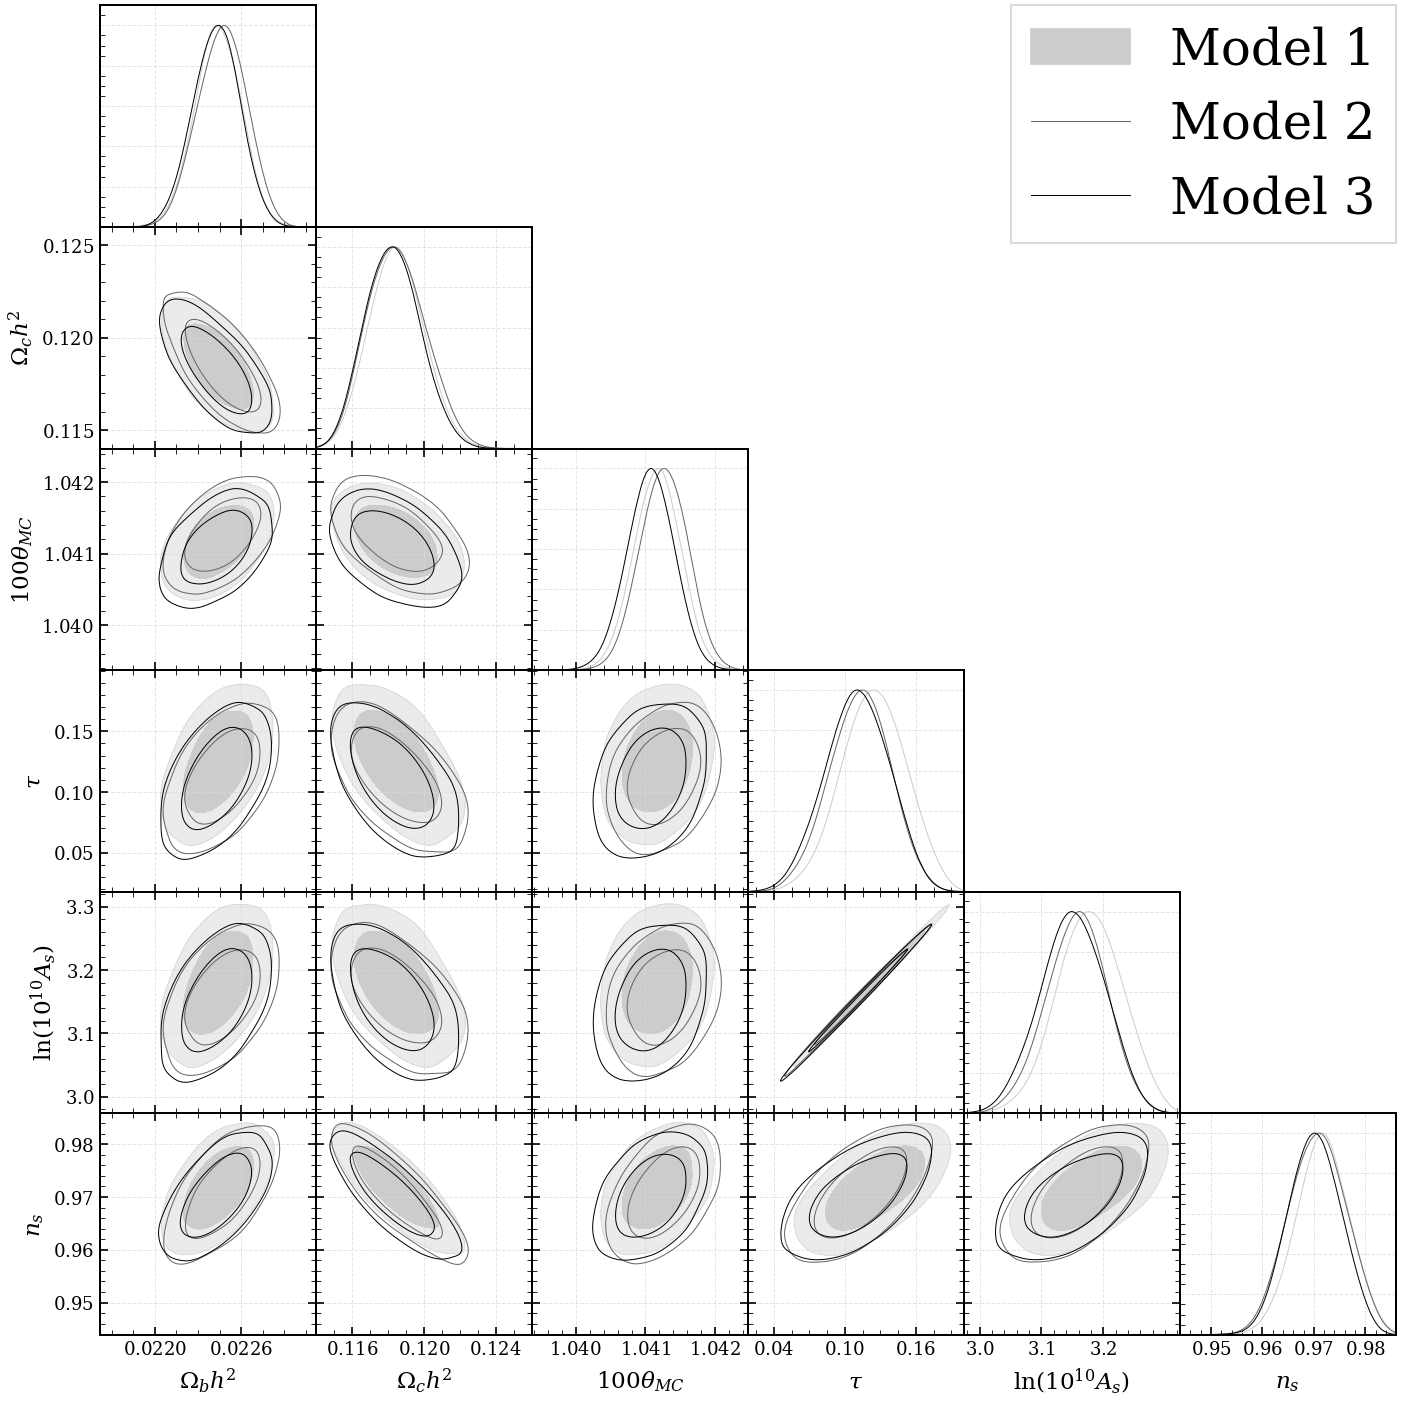

In [10]:
from zbi.utils.plotting import plot_ppc

plot_ppc(
    all_samples=all_samples,
    param_names=["ombh2", "omch2", "theta_mc", "tau", "logA", "ns"],
    param_labels=[r"\Omega_b h^2", r"\Omega_c h^2", r"100\theta_{MC}",
                   r"\tau", r"\ln(10^{10} A_s)", r"n_s"],
    sample_labels=["Model 1", "Model 2", "Model 3"],
    sample_colors=['#cccccc', '#666666', '#000000'],
    filled=[True, False, False],
    limits=[
        (0.02237 - 5*0.00015, 0.02237 + 5*0.00015),
        (0.1200 - 5*0.0012, 0.1200 + 5*0.0012),
        (1.04092 - 5*0.00031, 1.04092 + 5*0.00031),
        (0.0544 - 5*0.0073, 0.0544 + 20*0.0073),
        (3.044 - 5*0.014, 3.044 + 20*0.014),
        (0.9649 - 5*0.0042, 0.9649 + 5*0.0042),
    ],
    gdist_fine_bins=500,
    gdist_scaling_factor=0.1,
    legend_fontsize=30,
)
plt.show()

### 2.2 Convergencia con el número de simulaciones

Es útil preguntarse cómo se comporta el normalizing flow y la red de embedding con distinto número de simulaciones de entrenamiento. A continuación se entrenaron modelos con 5 000, 10 000, 20 000, 50 000, 100 000, 125 000, 150 000, 175 000, 3 modelos por cantidad:

```python
device = "cuda"
run_dir = "runs/planck_lite_r2"
runs = ['r1', 'r2', 'r3']

for n in [5000, 10000, 20000, 50000, 100000, 125000, 150000, 175000]:
    for r in runs:
        zbi.train(
            run_dir, round=0, n_sims=n,
            device=device, batch_size=64, lr=5e-4,
            max_epochs=2147483647, stop_after_epochs=20,
            load_to_ram=True, offset=0, tag=f"mlpv2_{r}"
        )
```

Se muestran los contornos 2D marginales de los 3 modelos del ensemble para cada cantidad de simulaciones, en el plano $\Omega_c h^2$ vs $n_s$.

In [11]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from getdist import MCSamples, chains, plots

n_samples = 10_000
n_cols = 3
n_rows = 3

ALL_PARAM_NAMES = ["ombh2", "omch2", "theta_mc", "tau", "logA", "ns"]
ALL_PARAM_LABELS = [
    r"\Omega_b h^2", r"\Omega_c h^2", r"100\theta_{MC}",
    r"\tau", r"\ln(10^{10} A_s)", r"n_s",
]

x_param = "omch2"
y_param = "ns"
PARAM_INFO = {
    "omch2": {"label": r"$\Omega_c h^2$", "center": 0.1200, "width": 0.0012},
    "ns":    {"label": r"$n_s$",          "center": 0.9649, "width": 0.0042},
}

ENSEMBLES = [
    [f"round_00000_{n}_mlpv2_{r}.pt" for r in ['r1', 'r2', 'r3']]
    for n in [5000, 10000, 20000, 50000, 100000, 125000, 150000, 175000, 200000]
]
SIM_COUNTS = [5000, 10000, 20000, 50000, 100000, 125000, 150000, 175000, 200000]

n_plots = n_rows * n_cols
x_info = PARAM_INFO[x_param]
y_info = PARAM_INFO[y_param]
x_lo = x_info["center"] - 5 * x_info["width"]
x_hi = x_info["center"] + 5 * x_info["width"]
y_lo = y_info["center"] - 5 * y_info["width"]
y_hi = y_info["center"] + 5 * y_info["width"]

ensembles = ENSEMBLES[:n_plots]
sim_counts = SIM_COUNTS[:n_plots]
colors = ["#cccccc", "#666666", "#000000"]

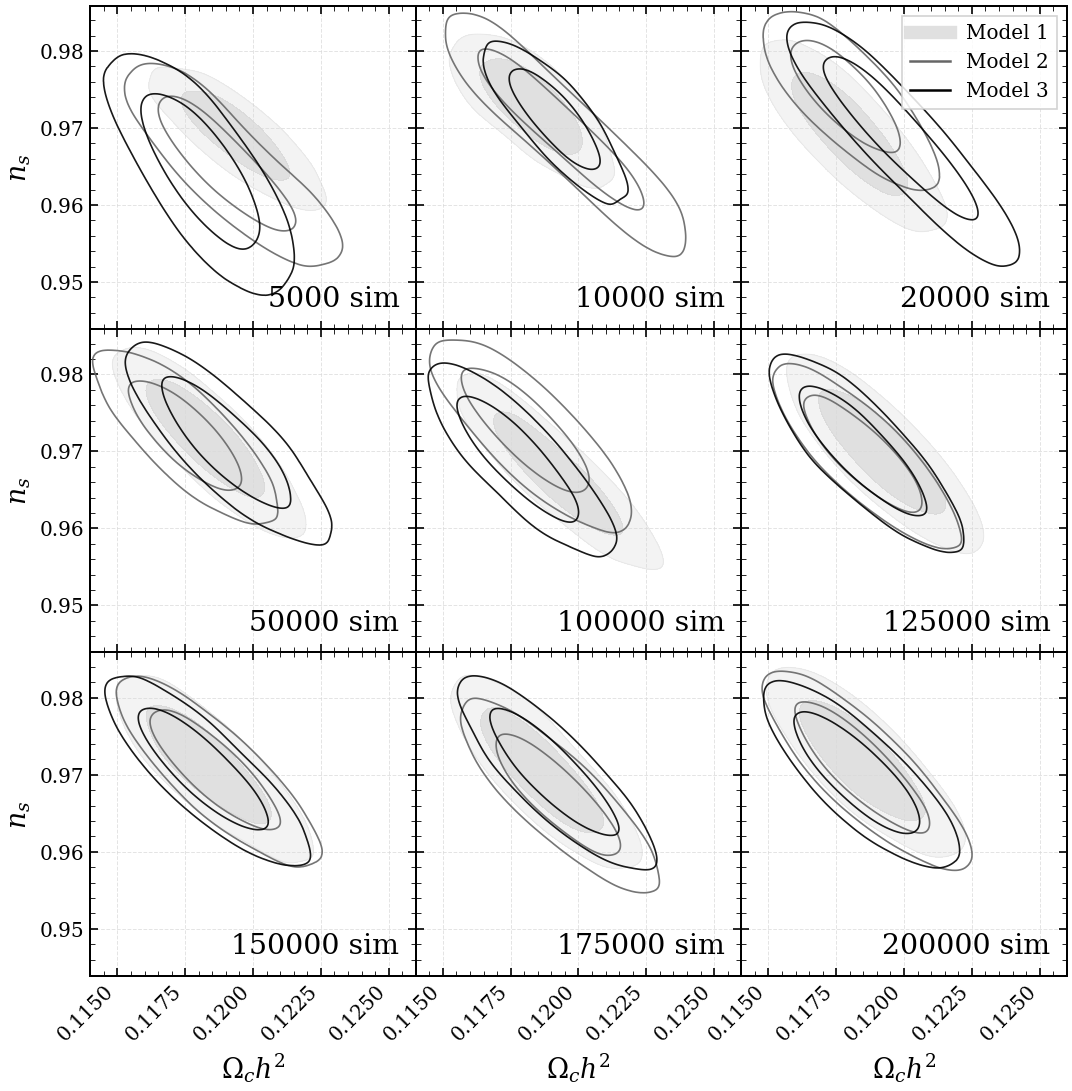

In [12]:
g = plots.get_subplot_plotter(subplot_size=3.5)
g.settings.scaling = False
g.make_figure(n_plots, nx=n_cols, ny=n_rows)

for idx in range(n_plots):
    row, col = divmod(idx, n_cols)
    g.subplots[row, col] = g.fig.add_subplot(g.gridspec[row, col])

for idx, (ensemble, count) in enumerate(zip(ensembles, sim_counts)):
    row, col = divmod(idx, n_cols)
    ax = g.subplots[row, col]

    gd_samples = []
    _orig_pld = chains.print_load_details
    chains.print_load_details = False
    try:
        for ckpt in ensemble:
            raw = sample_model(run_dir=run_dir, checkpoint=ckpt, n_samples=n_samples)
            gd = MCSamples(
                samples=np.array(raw, copy=True),
                names=ALL_PARAM_NAMES,
                labels=ALL_PARAM_LABELS,
            )
            gd.fine_bins = gd.fine_bins_2D = 500
            gd_samples.append(gd)
    finally:
        chains.print_load_details = _orig_pld

    for i, gd in enumerate(gd_samples):
        g.add_2d_contours(
            gd, x_param, y_param,
            ax=ax,
            filled=(i == 0),
            color=colors[i],
            alpha=0.6 if i == 0 else 0.9,
        )

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.4f}"))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

    if col == 0:
        ax.set_ylabel(y_info["label"], fontsize=16)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    if row == n_rows - 1:
        ax.set_xlabel(x_info["label"], fontsize=16)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    ax.text(
        0.95, 0.05, f"{count} sim",
        transform=ax.transAxes, fontsize=17, va="bottom", ha="right",
    )

    if row == 0 and col == n_cols - 1:
        proxy_filled = Line2D([0], [0], color=colors[0], lw=8, alpha=0.6)
        proxy_line1 = Line2D([0], [0], color=colors[1], lw=1.5)
        proxy_line2 = Line2D([0], [0], color=colors[2], lw=1.5)
        ax.legend(
            handles=[proxy_filled, proxy_line1, proxy_line2],
            labels=["Model 1", "Model 2", "Model 3"],
            fontsize=12, loc="upper right",
        )

g.fig.subplots_adjust(wspace=0, hspace=0)
plt.show()

### 2.3 Divergencia KL entre modelos

El gráfico anterior es útil de forma visual, pero necesitamos una forma cuantificable de comparar las posteriores de los modelos. Podemos volver a usar la divergencia KL que utilizamos en el entrenamiento. La matriz KL $K_{ij} = \mathrm{KL}(q_i \| q_j)$ mide cuánto diverge la distribución del modelo $i$ respecto al modelo $j$. Usaremos el máximo de esta matriz fuera de la diagonal para cuantificar la disimulitud entre los 3 modelos del ensemble.

In [13]:
from zbi.pipeline import kl_matrix_from_run

checkpoints_200k = [
    f"round_00000_200000_mlpv2_{r}.pt" for r in ['r1', 'r2', 'r3']
]

kl_200k = kl_matrix_from_run(
    run_dir=run_dir,
    checkpoints=checkpoints_200k,
    n_samples=10_000,
    device="cpu",
)

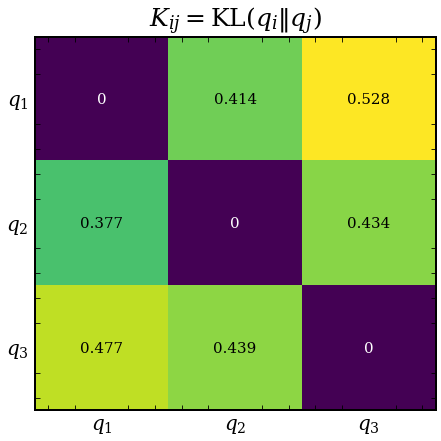

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(kl_200k, cmap="viridis", interpolation="nearest", aspect="auto")

ax.grid(False)

labels = [r"$q_1$", r"$q_2$", r"$q_3$"]
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.tick_params(length=0)

for i in range(3):
    for j in range(3):
        v = kl_200k[i, j]
        txt = "0" if i == j else f"{v:.3g}"
        nv = (v - kl_200k.min()) / (kl_200k.max() - kl_200k.min())
        tc = "white" if nv < 0.5 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=tc)

offdiag = kl_200k[~np.eye(3, dtype=bool)]
ax.set_title(r"$K_{ij} = \mathrm{KL}(q_i \| q_j)$")
plt.tight_layout()
plt.show()

El máximo de la matriz fuera de la diagonal indica la mayor discrepancia entre cualquier par de modelos. Si el ensemble converge, este valor debería decrecer a medida que aumenta el número de simulaciones.

In [15]:
sim_counts = [5000, 10000, 20000, 50000, 100000, 125000, 150000, 175000, 200000]
runs = ['r1', 'r2', 'r3']
max_kl_values = []

for n in sim_counts:
    checkpoints = [f"round_00000_{n}_mlpv2_{r}.pt" for r in runs]
    kl = kl_matrix_from_run(
        run_dir=run_dir, checkpoints=checkpoints,
        n_samples=10_000, device="cpu",
    )
    offdiag = kl[~np.eye(3, dtype=bool)]
    max_kl_values.append(float(np.max(offdiag)))

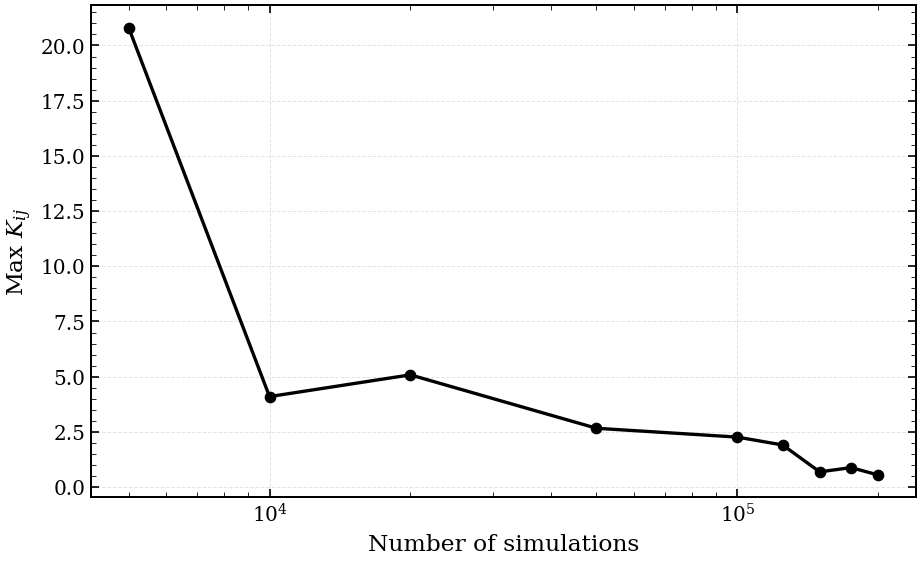

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(sim_counts, max_kl_values, "o-", color="black")
plt.xlabel("Number of simulations")
plt.ylabel(r"Max $K_{ij}$")
plt.xscale("log")
plt.tight_layout()
plt.show()

### 2.4 Comparación con MCMC

Para confirmar la convergencia a la real posterior, se usó Cobaya corriendo el script en `cmb/run_cobaya_mcmc.py`. A continuación se muestra una comparación entre una combinación de muestras de 10 modelos dentro de un ensamble de 200 000 simulaciones y una cadena de MCMC corrida con la likelihood implementada por la Planck Collaboration.

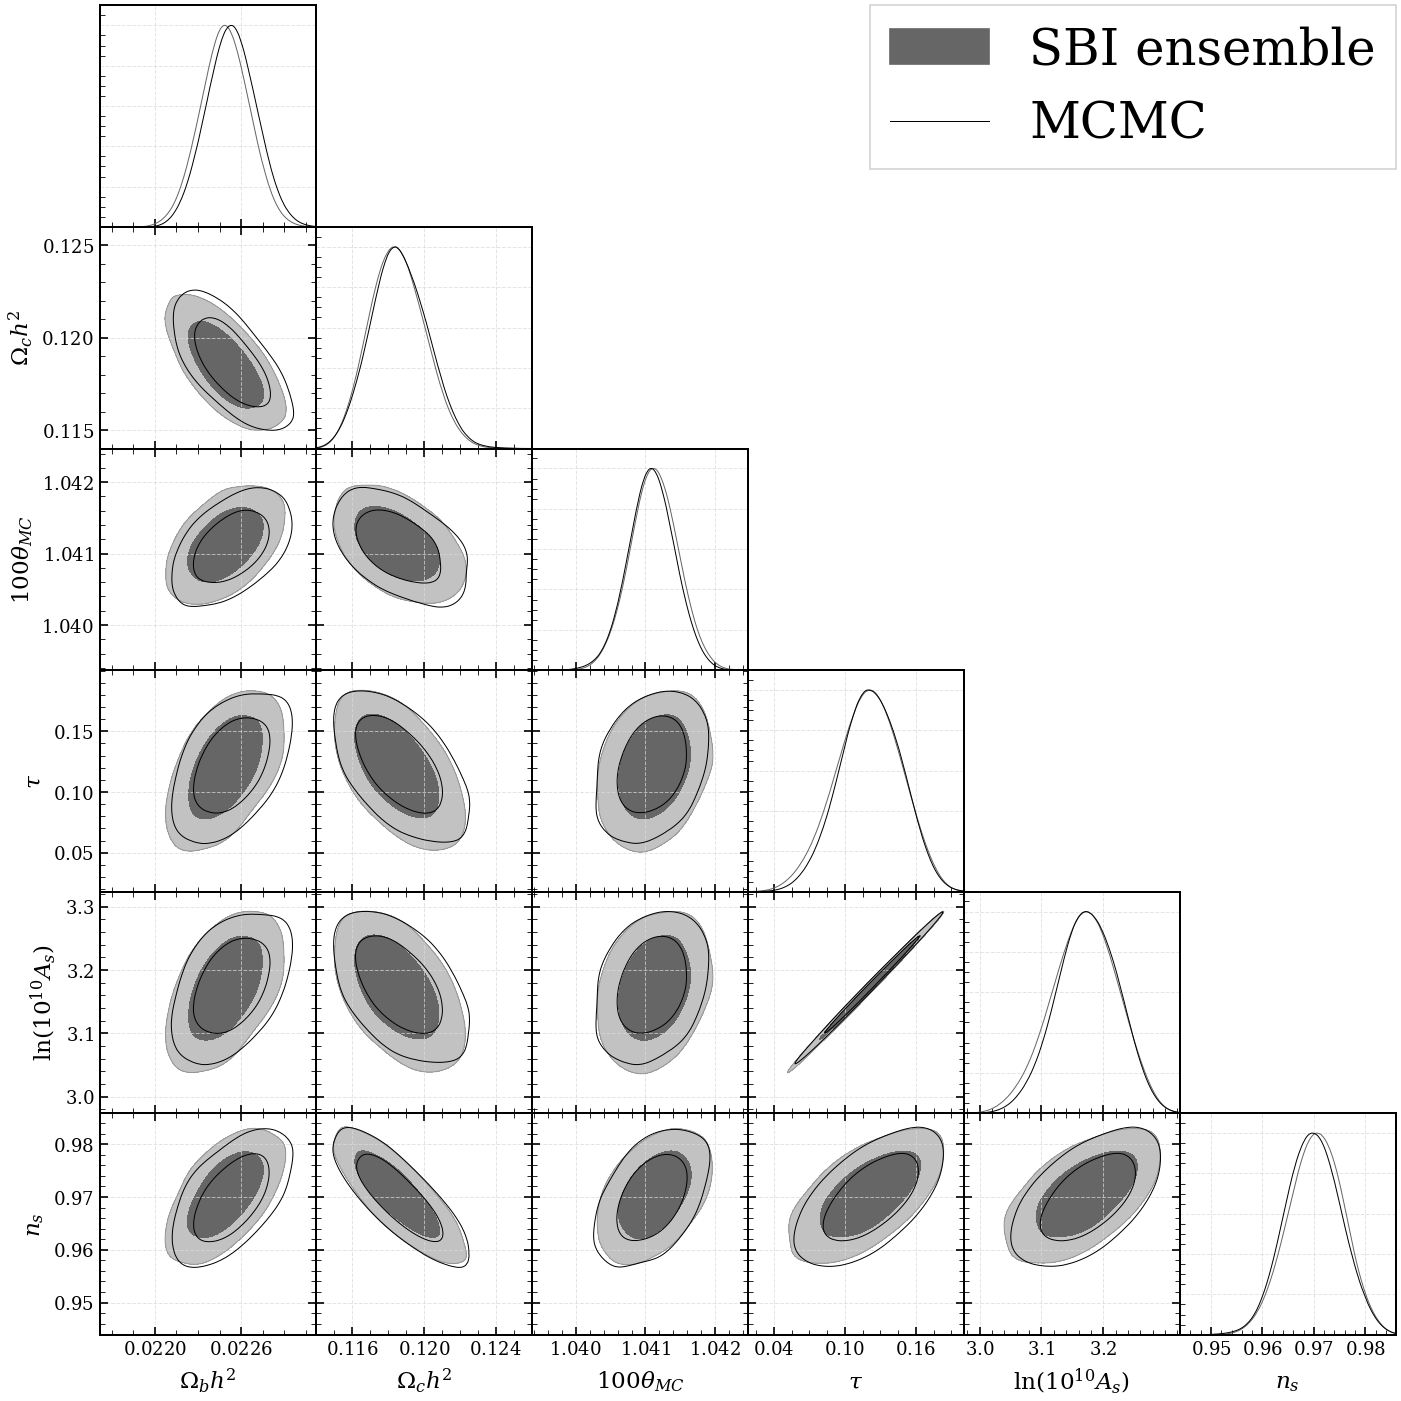

In [17]:
from cmb.load_chain import load_chain

chain_samples = load_chain("../chains/pliklite_r2")

runs = ['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9']
sbi_samples = []
for r in runs:
    s = sample_model(
        run_dir=run_dir, n_samples=1000,
        checkpoint=f"round_00000_200000_mlpv2_{r}.pt"
    )
    sbi_samples.append(s)

sbi_ensemble = np.concatenate(sbi_samples, axis=0)

plot_ppc(
    all_samples=[sbi_ensemble, chain_samples],
    param_names=["ombh2", "omch2", "theta_mc", "tau", "logA", "ns"],
    param_labels=[r"\Omega_b h^2", r"\Omega_c h^2", r"100\theta_{MC}",
                   r"\tau", r"\ln(10^{10} A_s)", r"n_s"],
    sample_labels=["SBI ensemble", "MCMC"],
    sample_colors=["#666666", "#000000"],
    filled=[True, False],
    limits=[
        (0.02237 - 5*0.00015, 0.02237 + 5*0.00015),
        (0.1200 - 5*0.0012, 0.1200 + 5*0.0012),
        (1.04092 - 5*0.00031, 1.04092 + 5*0.00031),
        (0.0544 - 5*0.0073, 0.0544 + 20*0.0073),
        (3.044 - 5*0.014, 3.044 + 20*0.014),
        (0.9649 - 5*0.0042, 0.9649 + 5*0.0042),
    ],
    gdist_fine_bins=500,
    gdist_scaling_factor=0.1,
    legend_fontsize=30,
)
plt.show()